<a href="https://colab.research.google.com/github/arunkumar-singh/drone_course_repo/blob/main/tutorials/quadrotor_trajectory_tracking_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚁 Perception and Control for Drones: 3D Trajectory Tracking Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunkumar-singh/drone_course_repo/blob/main/tutorials/quadrotor_trajectory_tracking_colab.ipynb)

Welcome to this advanced hands-on tutorial on **continuous 3D Trajectory Tracking** for an autonomous 6-DOF Quadrotor in Google Colab using **Gymnasium** and **MuJoCo**.

### Hierarchical Control Architecture
As derived in the course lectures, quadrotor flight control is decomposed into a **two-tier hierarchy**:
1. **High-Level Guidance Layer**: Operates on a **single-integrator model** ($\mathbf{\dot{p}} = \mathbf{v}_{\mathrm{cmd}}$) and generates 3D velocity commands.
2. **Black-Box Lower-Level Controller**: Sits between the high-level velocity commands and MuJoCo's 4 motor actuators, handling attitude dynamics, tilt compensation, and motor mixing.

<p align="center">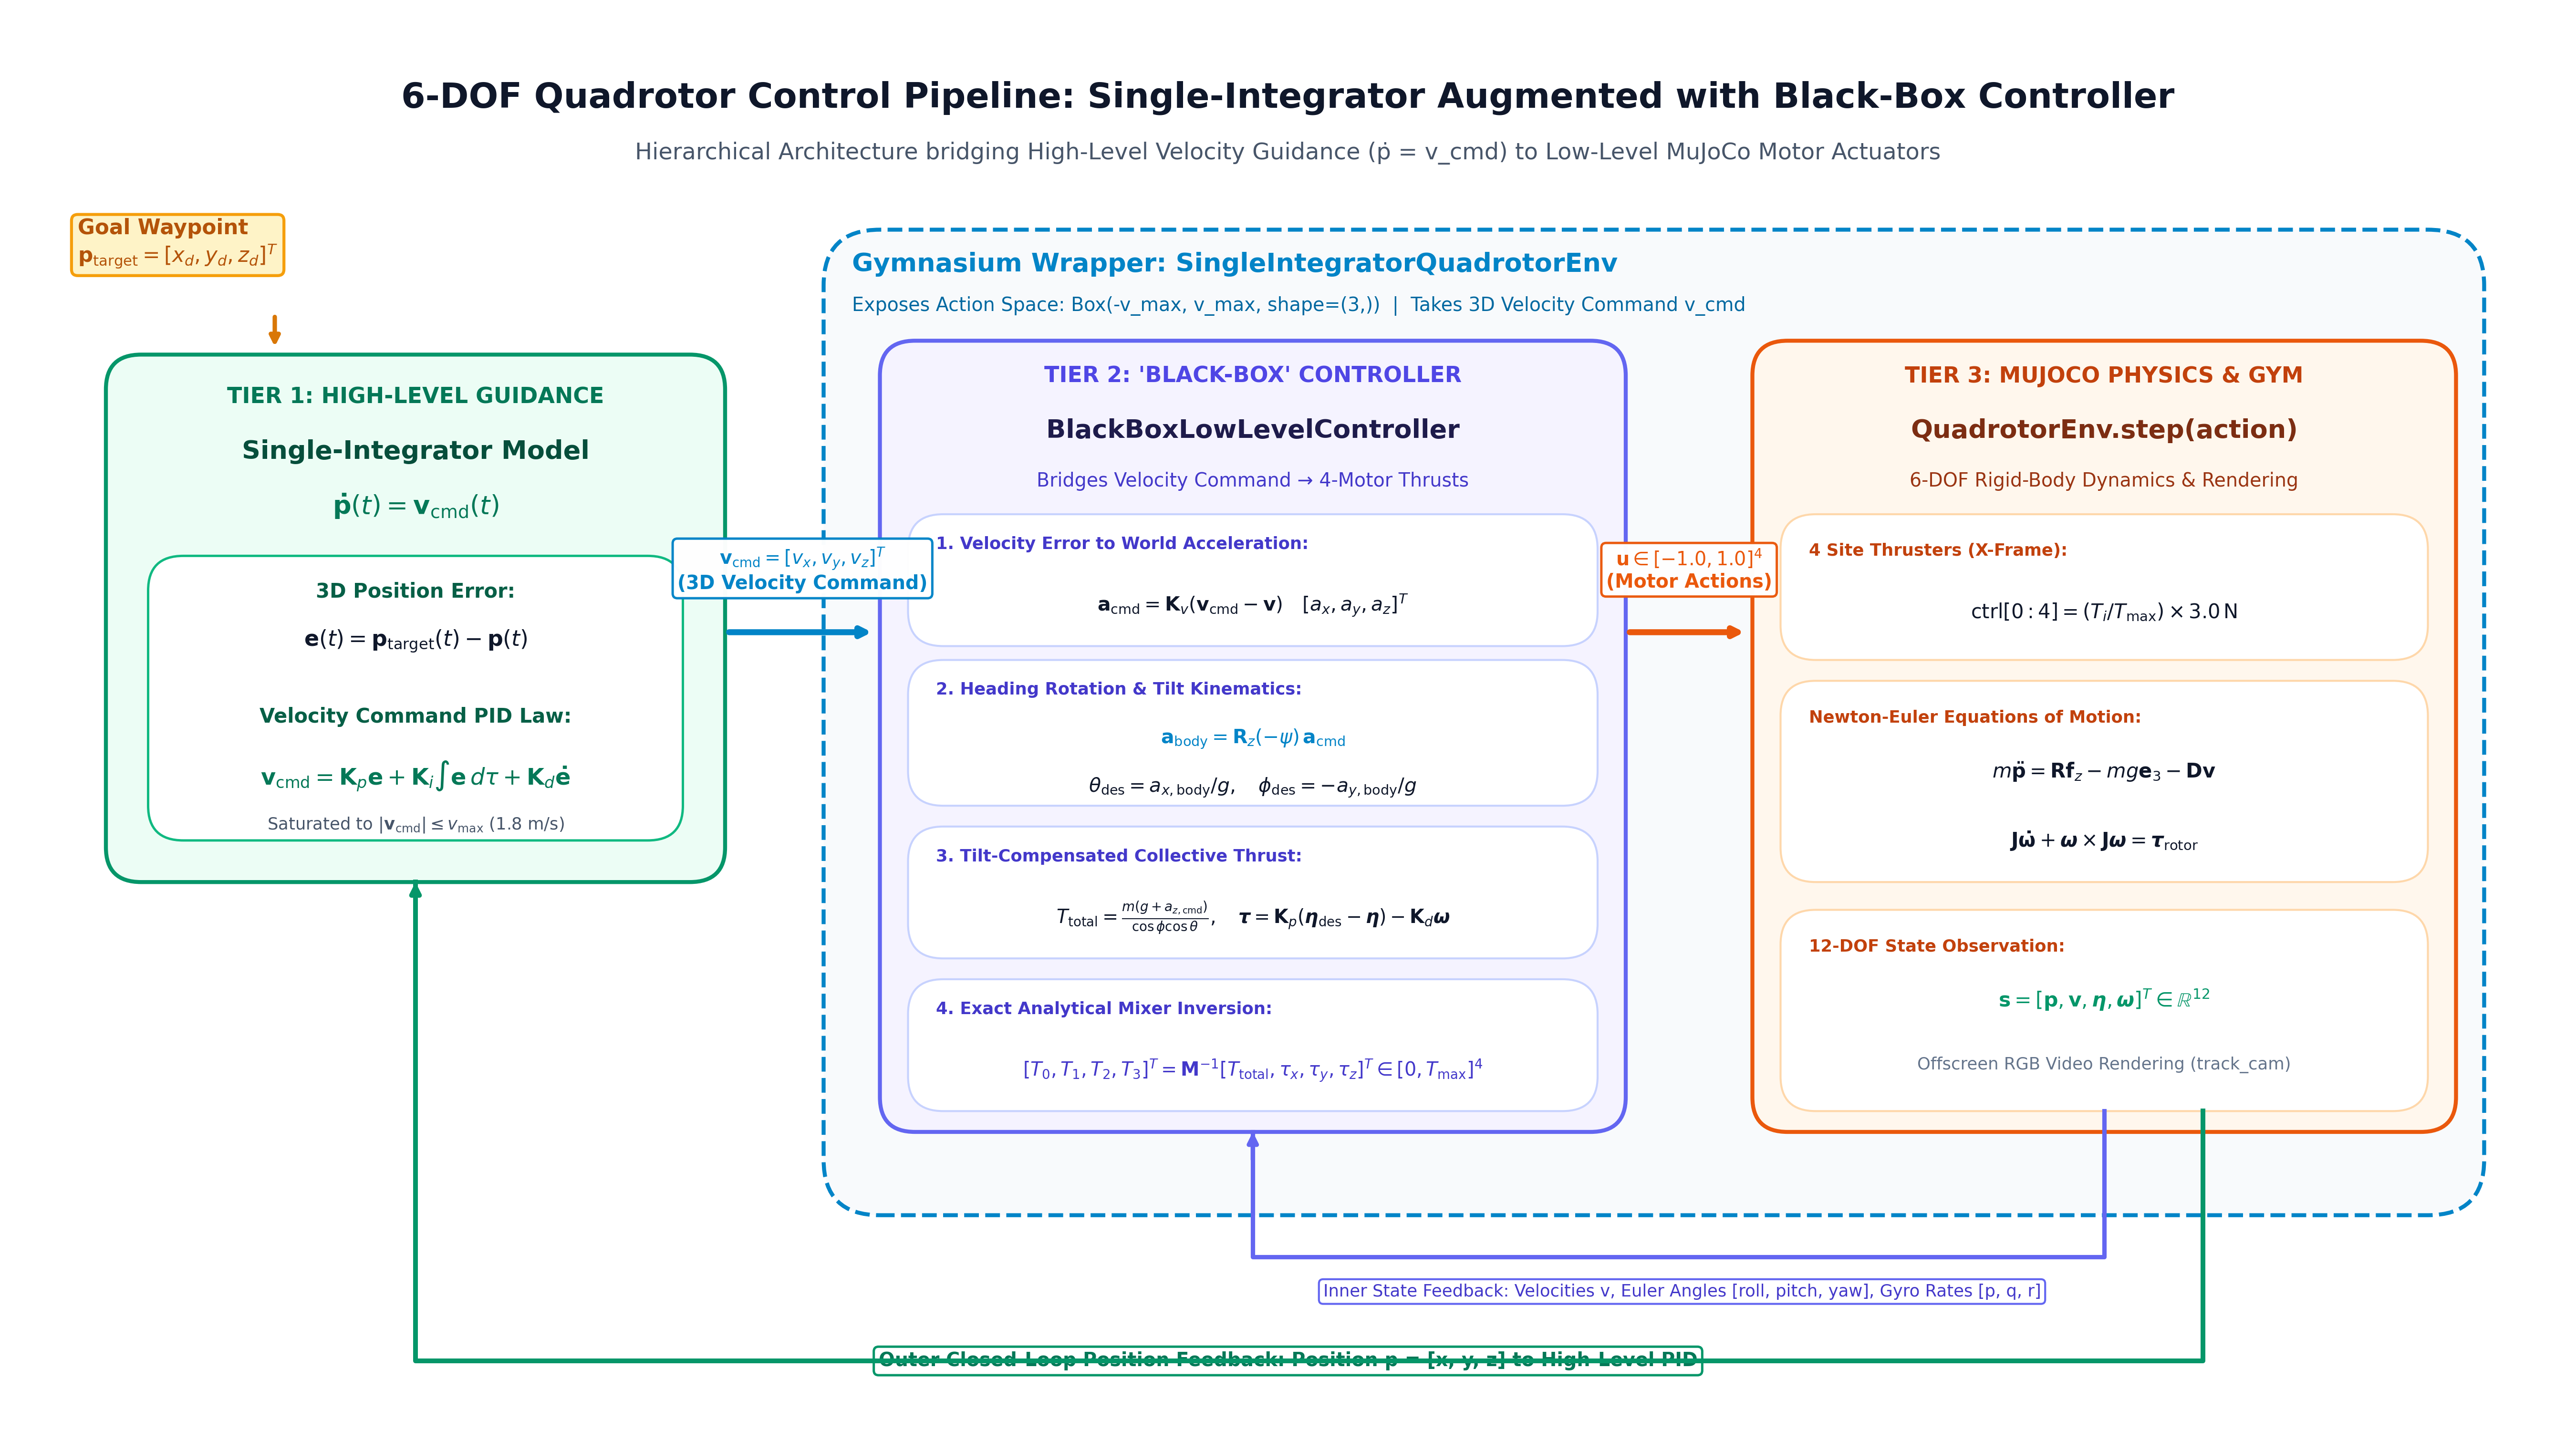</p>

### In This Tutorial, You Will Learn:
1. **Install Dependencies & EGL Setup**: Configure headless GPU rendering in Google Colab.
2. **Core Building Blocks**: Load the 6-DOF physics model (`QUADROTOR_XML`), Gymnasium environment (`QuadrotorEnv`), and the deterministic `BlackBoxLowLevelController`.
3. **Feedforward Trajectory Tracking Law**: Derive and implement why pure feedback PID lags behind moving targets, and how **velocity feedforward** ($\mathbf{v}_{\mathrm{cmd}} = \mathbf{v}_d + \mathbf{K}_p \mathbf{e}$) achieves zero-lag tracking.
4. **Experiment 1: Moving Point Interception & Tracking**: The drone starts with an initial offset from a moving target and smoothly converges to track it.
5. **Experiment 2: Full-Blown Trajectory Tracking Module**: A modular `TrajectoryGenerator` with **tunable flight speed** (`speed_scale`), continuous 3D Figure-8 flight, error metrics (RMSE), matplotlib performance plots, and in-notebook video rendering.

## 1. Install Dependencies & Configure Headless OpenGL

We configure MuJoCo to use **EGL** (`MUJOCO_GL="egl"`) for hardware-accelerated offscreen rendering in Google Colab without requiring an X11 desktop display.

In [1]:
# 1. Configure MuJoCo for headless GPU rendering (EGL) in Google Colab
import os
os.environ["MUJOCO_GL"] = "egl"

# 2. Install required packages
!pip install -q gymnasium mujoco mediapy matplotlib

# 3. Ensure EGL GLContext is bound to MuJoCo
import mujoco
try:
    import mujoco.egl
    mujoco.GLContext = mujoco.egl.GLContext
except Exception:
    pass

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import mediapy as media
import matplotlib.pyplot as plt

print(f"MuJoCo Version:         {mujoco.__version__}")
print(f"Active OpenGL Platform: {getattr(mujoco, 'GLContext', 'Default')}")
print(f"Gymnasium Version:      {gym.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 121.6 MB/s eta 0:00:00
MuJoCo Version:         3.12.0
Active OpenGL Platform: <class 'mujoco.egl.GLContext'>
Gymnasium Version:      1.3.0


## 2. The 6-DOF Quadrotor Model (MJCF XML)

We define the 6-DOF quadrotor in MuJoCo XML format:
- **Freejoint root**: Full 6-DOF rigid-body dynamics (mass $m = 0.500\text{ kg}$)
- **X-Configuration**: 4 thruster site actuators with counter-rotational yaw reaction torques
- **Mocap Target Sphere**: Visual golden sphere indicating the current 3D trajectory reference $\mathbf{p}_d(t)$
- **Cameras**: Third-person tracking camera (`track_cam`) and wide arena observer (`arena_cam`)

In [2]:
QUADROTOR_XML = """
<mujoco model="quadrotor">
  <compiler angle="radian" coordinate="local"/>
  <option gravity="0 0 -9.81" integrator="RK4" timestep="0.01"/>

  <visual>
    <headlight ambient="0.4 0.4 0.4" diffuse="0.8 0.8 0.8" specular="0.1 0.1 0.1"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20" offwidth="1280" offheight="720"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.7" rgb2="0.0 0.1 0.2" width="512" height="512"/>
    <texture name="grid" type="2d" builtin="checker" width="512" height="512" rgb1="0.25 0.35 0.45" rgb2="0.15 0.2 0.25"/>
    <material name="grid" texture="grid" texrepeat="2 2" texuniform="true" reflectance="0.2"/>
    <material name="chassis" rgba="0.15 0.15 0.15 1.0" specular="0.5" shininess="0.5"/>
    <material name="arm" rgba="0.25 0.25 0.25 1.0"/>
    <material name="front_prop" rgba="0.95 0.15 0.15 0.85" specular="0.4"/>
    <material name="rear_prop" rgba="0.15 0.45 0.95 0.85" specular="0.4"/>
    <material name="target_mat" rgba="1.0 0.8 0.0 0.85" specular="0.9"/>
  </asset>

  <worldbody>
    <light directional="true" diffuse="0.8 0.8 0.8" specular="0.3 0.3 0.3" pos="0 0 6.0" dir="0 0 -1"/>
    <light directional="true" diffuse="0.4 0.4 0.4" specular="0.1 0.1 0.1" pos="4 -4 5.0" dir="-1 1 -1"/>
    <geom name="floor" type="plane" size="14 14 0.1" material="grid" condim="3"/>

    <!-- Target Waypoint Sphere (Mocap Body) -->
    <body name="target" pos="0.0 0.0 1.0" mocap="true">
      <geom name="target_sphere" type="sphere" size="0.08" material="target_mat" contype="0" conaffinity="0" density="0"/>
    </body>

    <!-- Observer Cameras -->
    <camera name="arena_cam" pos="0.0 -4.5 3.5" xyaxes="1.0 0.0 0.0 0.0 0.6 0.8" mode="fixed"/>

    <!-- 6-DOF Quadrotor Body -->
    <body name="quadrotor" pos="0 0 1.0">
      <freejoint name="root"/>
      <camera name="track_cam" mode="trackcom" pos="0.0 -2.4 1.2" xyaxes="1.0 0.0 0.0 0.0 0.45 0.89"/>

      <!-- Central Fuselage -->
      <geom name="chassis_geom" type="box" size="0.06 0.06 0.02" material="chassis" mass="0.32"/>

      <!-- X-Configuration Arms (d = 0.12m offset) -->
      <geom name="arm_fr" type="capsule" fromto="0 0 0  0.12  0.12 0" size="0.008" material="arm" mass="0.03"/>
      <geom name="arm_rr" type="capsule" fromto="0 0 0 -0.12  0.12 0" size="0.008" material="arm" mass="0.03"/>
      <geom name="arm_rl" type="capsule" fromto="0 0 0 -0.12 -0.12 0" size="0.008" material="arm" mass="0.03"/>
      <geom name="arm_fl" type="capsule" fromto="0 0 0  0.12 -0.12 0" size="0.008" material="arm" mass="0.03"/>

      <!-- Rotor Visual Discs -->
      <geom name="prop_0" type="cylinder" pos=" 0.12  0.12 0.01" size="0.045 0.003" material="front_prop" mass="0.015"/>
      <geom name="prop_1" type="cylinder" pos="-0.12  0.12 0.01" size="0.045 0.003" material="rear_prop"  mass="0.015"/>
      <geom name="prop_2" type="cylinder" pos="-0.12 -0.12 0.01" size="0.045 0.003" material="rear_prop"  mass="0.015"/>
      <geom name="prop_3" type="cylinder" pos=" 0.12 -0.12 0.01" size="0.045 0.003" material="front_prop" mass="0.015"/>

      <!-- Rotor Thruster Sites -->
      <site name="motor0_site" pos=" 0.12  0.12 0.01" size="0.01"/>
      <site name="motor1_site" pos="-0.12  0.12 0.01" size="0.01"/>
      <site name="motor2_site" pos="-0.12 -0.12 0.01" size="0.01"/>
      <site name="motor3_site" pos=" 0.12 -0.12 0.01" size="0.01"/>
    </body>
  </worldbody>

  <actuator>
    <general name="motor0" site="motor0_site" gear="0 0 1 0 0  0.015" ctrlrange="0 3.0" ctrllimited="true"/>
    <general name="motor1" site="motor1_site" gear="0 0 1 0 0 -0.015" ctrlrange="0 3.0" ctrllimited="true"/>
    <general name="motor2" site="motor2_site" gear="0 0 1 0 0  0.015" ctrlrange="0 3.0" ctrllimited="true"/>
    <general name="motor3" site="motor3_site" gear="0 0 1 0 0 -0.015" ctrlrange="0 3.0" ctrllimited="true"/>
  </actuator>
</mujoco>
"""
print("Quadrotor MJCF XML successfully defined!")

Quadrotor MJCF XML successfully defined!


## 3. Base Gymnasium Environment (`QuadrotorEnv`)

Implements standard Gymnasium methods (`reset`, `step`, `render`) with offscreen RGB rendering.

In [3]:
# Ensure headless OpenGL platform (EGL / OSMesa) is active for Colab rendering
if "MUJOCO_GL" not in os.environ:
    os.environ["MUJOCO_GL"] = "egl"
try:
    import mujoco.egl
    mujoco.GLContext = mujoco.egl.GLContext
except Exception:
    try:
        import mujoco.osmesa
        mujoco.GLContext = mujoco.osmesa.GLContext
    except Exception:
        pass

class QuadrotorEnv(gym.Env):
    """
    Base 6-DOF Quadrotor Gymnasium Environment.
    Low-level interface expects 4-motor thrust action commands in [-1.0, 1.0].
    """
    metadata = {"render_modes": ["rgb_array"], "render_fps": 30}

    def __init__(
        self,
        xml_string=QUADROTOR_XML,
        target_pos=(0.0, 0.0, 1.0),
        dt=0.01,
        frame_skip=2,
        max_steps=500,
        camera_name="track_cam",
        render_width=720,
        render_height=540,
    ):
        super().__init__()

        self.model = mujoco.MjModel.from_xml_string(xml_string)
        self.model.opt.timestep = dt
        self.data = mujoco.MjData(self.model)

        self.dt = dt
        self.frame_skip = frame_skip
        self.max_steps = max_steps
        self.camera_name = camera_name
        self.target_pos = np.array(target_pos, dtype=np.float32)

        # 4-motor Action Space in [-1.0, 1.0]
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(self.model.nu,), dtype=np.float32
        )

        # 12-dimensional State Observation Space
        high_obs = np.array([
            10.0, 10.0, 10.0,     # pos (m)
            20.0, 20.0, 20.0,     # vel (m/s)
            np.pi, np.pi, np.pi,  # roll, pitch, yaw (rad)
            20.0, 20.0, 20.0,     # p, q, r (rad/s)
        ], dtype=np.float32)
        self.observation_space = spaces.Box(low=-high_obs, high=high_obs, dtype=np.float32)

        self.current_step = 0
        self.renderer = mujoco.Renderer(self.model, height=render_height, width=render_width)

    def set_target_pos(self, target_pos):
        """Update target waypoint position in physics & visualizer."""
        self.target_pos = np.array(target_pos, dtype=np.float32)
        self.data.mocap_pos[0] = self.target_pos

    def _quat_to_euler(self, q):
        w, x, y, z = q
        sinr_cosp = 2.0 * (w * x + y * z)
        cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
        roll = np.arctan2(sinr_cosp, cosr_cosp)

        sinp = np.clip(2.0 * (w * y - z * x), -1.0, 1.0)
        pitch = np.arcsin(sinp)

        siny_cosp = 2.0 * (w * z + x * y)
        cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
        yaw = np.arctan2(siny_cosp, cosy_cosp)
        return np.array([roll, pitch, yaw], dtype=np.float32)

    def _get_obs(self):
        pos = np.array(self.data.qpos[0:3], dtype=np.float32)
        quat = self.data.qpos[3:7]
        euler = self._quat_to_euler(quat)
        vel = np.array(self.data.qvel[0:3], dtype=np.float32)
        omega = np.array(self.data.qvel[3:6], dtype=np.float32)
        return np.concatenate([pos, vel, euler, omega])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.model, self.data)
        self.current_step = 0

        # Quadrotor initial state
        self.data.qpos[0:3] = [0.0, 0.0, 1.0]
        self.data.qpos[3:7] = [1.0, 0.0, 0.0, 0.0]  # identity quat
        self.data.qvel[:] = 0.0
        self.set_target_pos(self.target_pos)

        mujoco.mj_forward(self.model, self.data)
        return self._get_obs(), {}

    def step(self, action):
        self.current_step += 1
        # Scale normalized action [-1, 1] to motor thrust [0, 3.0] N
        thrust_cmd = (np.clip(action, -1.0, 1.0) + 1.0) * 0.5 * 3.0
        self.data.ctrl[:] = thrust_cmd

        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)

        obs = self._get_obs()
        pos = obs[0:3]
        dist = np.linalg.norm(pos - self.target_pos)
        reward = -float(dist)
        terminated = bool(pos[2] < 0.15 or pos[2] > 6.0)
        truncated = bool(self.current_step >= self.max_steps)
        return obs, reward, terminated, truncated, {"error": dist}

    def render(self):
        self.renderer.update_scene(self.data, camera=self.camera_name)
        return self.renderer.render()

    def close(self):
        if hasattr(self, 'renderer'):
            self.renderer.close()

print("Base QuadrotorEnv class successfully defined!")

Base QuadrotorEnv class successfully defined!


## 4. The "Black-Box" Lower-Level Bridge & Single-Integrator Wrapper

The `BlackBoxLowLevelController` automatically translates a 3D velocity command $\mathbf{v}_{\mathrm{cmd}}$ into the 4 motor thrust actions $[T_0, T_1, T_2, T_3]$.

In [4]:
class BlackBoxLowLevelController:
    """
    Deterministic Lower-Level Flight Controller.
    Bridges high-level 3D velocity commands v_cmd to MuJoCo 4-rotor thrust actuators.
    """
    def __init__(self, mass=0.500, g=9.81, max_thrust=3.0, d=0.12, c_tau=0.015):
        self.mass = mass
        self.g = g
        self.max_thrust = max_thrust
        self.hover_thrust = mass * g / 4.0
        self.d = d
        self.c_tau = c_tau

        # Velocity error -> acceleration gains
        self.kv_xy = 3.2
        self.kv_z = 6.0

        # Attitude tracking PD gains
        self.kp_att = 0.08
        self.kd_att = 0.016
        self.kp_yaw = 0.025
        self.kd_yaw = 0.006

    def compute_motor_action(self, v_cmd, obs, yaw_des=0.0):
        pos, vel, euler, omega = obs[0:3], obs[3:6], obs[6:9], obs[9:12]
        roll, pitch, yaw = euler
        p, q, r = omega

        # 1. Outer Velocity Tracking -> Commanded World Acceleration
        a_cmd_world_x = self.kv_xy * (v_cmd[0] - vel[0])
        a_cmd_world_y = self.kv_xy * (v_cmd[1] - vel[1])
        a_cmd_world_z = self.kv_z  * (v_cmd[2] - vel[2])

        # 2. Heading Rotation (Decouple horizontal acceleration from yaw)
        cos_psi, sin_psi = np.cos(yaw), np.sin(yaw)
        a_body_x =  cos_psi * a_cmd_world_x + sin_psi * a_cmd_world_y
        a_body_y = -sin_psi * a_cmd_world_x + cos_psi * a_cmd_world_y

        # 3. Inversion of Translational Kinematics -> Desired Tilt Angles
        pitch_des = np.clip( a_body_x / self.g, -0.28, 0.28)
        roll_des  = np.clip(-a_body_y / self.g, -0.28, 0.28)

        # 4. Attitude Restoration Moments with angle wrap minimization
        yaw_err = np.arctan2(np.sin(yaw_des - yaw), np.cos(yaw_des - yaw))
        tau_x = self.kp_att * (roll_des  - roll)  - self.kd_att * p
        tau_y = self.kp_att * (pitch_des - pitch) - self.kd_att * q
        tau_z = self.kp_yaw * yaw_err             - self.kd_yaw * r

        # 5. Tilt-Compensated Collective Thrust
        tilt_comp = max(0.65, np.cos(roll) * np.cos(pitch))
        total_thrust = (self.mass * (self.g + a_cmd_world_z)) / tilt_comp
        total_thrust = np.clip(total_thrust, 0.1 * self.mass * self.g, 1.95 * self.mass * self.g)

        # 6. Exact Analytical Mixer Inversion
        T_base = total_thrust / 4.0
        dT_x   = tau_x / (4.0 * self.d)
        dT_y   = tau_y / (4.0 * self.d)
        dT_z   = tau_z / (4.0 * self.c_tau)

        T0 = T_base + dT_x - dT_y + dT_z
        T1 = T_base + dT_x + dT_y - dT_z
        T2 = T_base - dT_x + dT_y + dT_z
        T3 = T_base - dT_x - dT_y - dT_z

        # 7. Normalize into [-1.0, 1.0] for MuJoCo
        thrusts = np.clip([T0, T1, T2, T3], 0.0, self.max_thrust)
        action = (thrusts / (0.5 * self.max_thrust)) - 1.0
        return action.astype(np.float32)


class SingleIntegratorQuadrotorEnv(gym.Wrapper):
    """
    Gymnasium Wrapper that abstracts the Quadrotor as a Single-Integrator:
    Action: 3D Velocity Command v_cmd = [vx, vy, vz]
    """
    def __init__(self, env, v_max=2.5):
        super().__init__(env)
        self.v_max = v_max
        self.controller = BlackBoxLowLevelController()
        self.action_space = spaces.Box(
            low=-v_max, high=v_max, shape=(3,), dtype=np.float32
        )

    def set_target_pos(self, target_pos):
        return self.env.set_target_pos(target_pos)

    def step(self, v_cmd, yaw_des=0.0):
        obs = self.env._get_obs()
        v_cmd_clipped = np.clip(v_cmd, -self.v_max, self.v_max)
        motor_action = self.controller.compute_motor_action(v_cmd_clipped, obs, yaw_des=yaw_des)
        return self.env.step(motor_action)

print("BlackBoxLowLevelController and SingleIntegratorQuadrotorEnv defined!")

BlackBoxLowLevelController and SingleIntegratorQuadrotorEnv defined!


## 5. Feedforward Trajectory Tracking Controller (`TrajectoryTrackingPID`)

When tracking a moving trajectory $\mathbf{p}_d(t)$, pure feedback PID will **always lag behind** because it requires an error to produce velocity.

By adding **velocity feedforward** $\mathbf{v}_d(t) = \dot{\mathbf{p}}_d(t)$:
$$\mathbf{v}_{\mathrm{cmd}}(t) = \mathbf{v}_d(t) + \mathbf{K}_p (\mathbf{p}_d(t) - \mathbf{p}(t)) + \mathbf{K}_i \int_0^t \mathbf{e}(\tau)\,d\tau + \mathbf{K}_d (\mathbf{v}_d(t) - \mathbf{v}(t))$$
- When the drone is on the path ($\mathbf{e} = \mathbf{0}$), it cruises smoothly at the trajectory speed $\mathbf{v}_d(t)$!
- Feedback terms quickly correct any deviation caused by gusts or initial offsets.

In [5]:
class TrajectoryTrackingPID:
    """
    Feedforward + Feedback Position Tracking Controller for Single-Integrator Drone.
    """
    def __init__(self, kp=2.5, ki=0.4, kd=0.5, v_max=2.5, max_int=0.8):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.v_max = v_max
        self.max_int = max_int
        self.integral_error = np.zeros(3, dtype=np.float32)
        self.prev_error = np.zeros(3, dtype=np.float32)

    def reset(self):
        self.integral_error = np.zeros(3, dtype=np.float32)
        self.prev_error = np.zeros(3, dtype=np.float32)

    def compute(self, current_pos, current_vel, target_pos, target_vel=None, dt=0.02):
        error = target_pos - current_pos
        dist = np.linalg.norm(error)

        # Anti-windup integration
        if dist < 1.0:
            self.integral_error = np.clip(
                self.integral_error + error * dt,
                -self.max_int, self.max_int
            )

        # Velocity feedforward (defaults to zeros if tracking a stationary point)
        v_ff = np.zeros(3, dtype=np.float32) if target_vel is None else np.array(target_vel, dtype=np.float32)

        # Proportional feedback
        p_term = self.kp * error

        # Integral feedback
        i_term = self.ki * self.integral_error

        # Derivative feedback on velocity error (target_vel - current_vel)
        d_term = self.kd * (v_ff - current_vel)

        # Total commanded velocity: Feedforward + Feedback
        v_cmd = v_ff + p_term + i_term + d_term

        # Speed limit saturation
        speed = np.linalg.norm(v_cmd)
        if speed > self.v_max:
            v_cmd = (v_cmd / speed) * self.v_max

        self.prev_error = error
        return v_cmd.astype(np.float32)

print("TrajectoryTrackingPID class successfully defined!")

TrajectoryTrackingPID class successfully defined!


## 6. Coding Block 1: Simple Tracking of a Moving Point

### Problem Scenario:
- **Moving Target**: A target point moves in a continuous circular orbit: $\mathbf{p}_{\mathrm{target}}(t) = [R\cos(\omega t), R\sin(\omega t), z_0 + A_z \sin(\omega_z t)]^T$.
- **Initial Offset**: The quadrotor begins at $[0.0, 0.0, 1.0]$ while the target starts at $[1.5, 0.0, 1.5]$ and is already moving!
- **Task**: The quadrotor must intercept the moving point from its initial spatial offset, smoothly close the gap, and lock onto it.

In [6]:
# =========================================================================
# EXPERIMENT 1: MOVING POINT TRACKING WITH INITIAL OFFSET
# =========================================================================

# 1. Define Moving Target Kinematics
radius = 5.4
omega = 0.45  # rad/s angular speed
z_base = 1.5
z_amp = 0.3

def get_moving_point(t):
    x = radius * np.cos(omega * t)
    y = radius * np.sin(omega * t)
    z = z_base + z_amp * np.sin(0.5 * omega * t)

    vx = -radius * omega * np.sin(omega * t)
    vy =  radius * omega * np.cos(omega * t)
    vz =  0.5 * omega * z_amp * np.cos(0.5 * omega * t)
    return np.array([x, y, z]), np.array([vx, vy, vz])

# 2. Instantiate Environment & Tracking Controller
base_env = QuadrotorEnv(camera_name="track_cam", max_steps=400)
env = SingleIntegratorQuadrotorEnv(base_env, v_max=2.5)
pid = TrajectoryTrackingPID(kp=2.8, ki=0.3, kd=0.5, v_max=2.5)

obs, _ = env.reset(seed=42)
# Drone starts at [0, 0, 1.0]
p_target_0, v_target_0 = get_moving_point(0.0)
env.set_target_pos(p_target_0)

initial_offset = np.linalg.norm(obs[0:3] - p_target_0)
print(f"Drone Start Pos:        {obs[0:3]}")
print(f"Moving Target Pos (t=0): {p_target_0}")
print(f"Initial Offset Gap:     {initial_offset:.2f} meters\n")

frames_exp1 = [env.render()]
dt_ctrl = 0.02  # 50 Hz control loop
t = 0.0
errors = []

print("--- Executing Moving Point Interception & Tracking ---")
for step in range(1, 350):
    t += dt_ctrl
    p_d, v_d = get_moving_point(t)

    # Update visual mocap target in simulation
    env.set_target_pos(p_d)

    current_pos = obs[0:3]
    current_vel = obs[3:6]
    dist = np.linalg.norm(current_pos - p_d)
    errors.append(dist)

    # Compute feedforward velocity command
    v_cmd = pid.compute(current_pos, current_vel, p_d, v_d, dt=dt_ctrl)

    # Step environment directly with v_cmd
    obs, reward, terminated, truncated, _ = env.step(v_cmd)
    frames_exp1.append(env.render())

    if step % 50 == 0:
        print(f"Step {step:03d} (t={t:4.1f}s) | Target: [{p_d[0]:5.2f}, {p_d[1]:5.2f}, {p_d[2]:5.2f}] | Drone: [{current_pos[0]:5.2f}, {current_pos[1]:5.2f}, {current_pos[2]:5.2f}] | Gap: {dist*100:5.1f} cm")

    if terminated or truncated:
        break

env.close()

# Telemetry summary
errors = np.array(errors)
print(f"\nInterception Complete!")
print(f"Initial Offset:      {initial_offset:.2f} m")
print(f"Final 50-step RMSE:  {np.sqrt(np.mean(errors[-50:]**2))*100:.1f} cm (Smooth Locked Tracking)")

# Display in-notebook video
print("\nDisplaying Interception & Tracking Video:")
media.show_video(frames_exp1, fps=30)

Drone Start Pos:        [0. 0. 1.]
Moving Target Pos (t=0): [1.4 0.  1.5]
Initial Offset Gap:     1.49 meters

--- Executing Moving Point Interception & Tracking ---
Step 050 (t= 1.0s) | Target: [ 1.26,  0.61,  1.57] | Drone: [ 0.85,  0.58,  1.46] | Gap:  42.4 cm
Step 100 (t= 2.0s) | Target: [ 0.87,  1.10,  1.63] | Drone: [ 1.42,  1.04,  1.63] | Gap:  55.4 cm
Step 150 (t= 3.0s) | Target: [ 0.31,  1.37,  1.69] | Drone: [ 0.22,  1.34,  1.70] | Gap:   8.8 cm
Step 200 (t= 4.0s) | Target: [-0.32,  1.36,  1.73] | Drone: [-0.44,  1.43,  1.74] | Gap:  14.1 cm
Step 250 (t= 5.0s) | Target: [-0.88,  1.09,  1.77] | Drone: [-0.91,  1.18,  1.78] | Gap:  10.0 cm
Step 300 (t= 6.0s) | Target: [-1.27,  0.60,  1.79] | Drone: [-1.22,  0.62,  1.80] | Gap:   5.1 cm

Interception Complete!
Initial Offset:      1.49 m
Final 50-step RMSE:  10.2 cm (Smooth Locked Tracking)

Displaying Interception & Tracking Video:


This browser does not support the video tag.


## 7. Coding Block 2: Full-Blown Trajectory Tracking Module

In this section, we implement:
1. **`TrajectoryGenerator` Class**: Generates a smooth, continuous 3D Figure-8 Lissajous curve with exact analytical positions $\mathbf{p}_d(t)$, velocities $\mathbf{v}_d(t)$, and accelerations $\mathbf{a}_d(t)$.
2. **Tunable Speed Parameter (`speed_scale`)**: Easily scale the cruising velocity along the trajectory to test slow, nominal, and aggressive high-speed tracking.
3. **Comprehensive Evaluation**: Root-Mean-Square Error (RMSE), 3D spatial trajectory plots, $x, y, z$ time histories, and in-notebook HD video rendering.

In [7]:
class TrajectoryGenerator:
    """
    3D Trajectory Generator for Continuous Quadrotor Flight.
    Implements a 3D Lemniscate of Bernoulli (Figure-8) with analytical derivatives.
    """
    def __init__(self, A=1.8, B=1.4, z_center=1.6, z_amp=0.35, base_period=16.0, speed_scale=1.0):
        """
        Parameters:
            A, B: Horizontal dimensions (m)
            z_center, z_amp: Altitude mean and vertical oscillation amplitude (m)
            base_period: Nominal duration of one full circuit (seconds)
            speed_scale: Tunable parameter! (1.0 = nominal, 1.5 = fast, 0.7 = slow)
        """
        self.A = A
        self.B = B
        self.z_center = z_center
        self.z_amp = z_amp
        self.speed_scale = speed_scale

        # Effective period and fundamental frequency
        self.period = base_period / speed_scale
        self.omega = 2.0 * np.pi / self.period

    def eval(self, t):
        """
        Evaluates position p(t), velocity v(t), and acceleration a(t) at time t.
        """
        w = self.omega

        # 1. Reference Position
        px = self.A * np.sin(w * t)
        py = self.B * np.sin(2.0 * w * t)
        pz = self.z_center + self.z_amp * np.cos(w * t)
        pos = np.array([px, py, pz], dtype=np.float32)

        # 2. Feedforward Velocity (First Time Derivative)
        vx =  self.A * w * np.cos(w * t)
        vy =  2.0 * self.B * w * np.cos(2.0 * w * t)
        vz = -self.z_amp * w * np.sin(w * t)
        vel = np.array([vx, vy, vz], dtype=np.float32)

        # 3. Feedforward Acceleration (Second Time Derivative)
        ax = -self.A * (w**2) * np.sin(w * t)
        ay = -4.0 * self.B * (w**2) * np.sin(2.0 * w * t)
        az = -self.z_amp * (w**2) * np.cos(w * t)
        acc = np.array([ax, ay, az], dtype=np.float32)

        # 4. Tangent Heading Angle (Faces along velocity vector)
        yaw_tangent = np.arctan2(vy, vx)

        return pos, vel, acc, yaw_tangent

print("TrajectoryGenerator successfully initialized!")

TrajectoryGenerator successfully initialized!


In [8]:
# =========================================================================
# EXPERIMENT 2: FULL-BLOWN TRAJECTORY TRACKING SIMULATION
# =========================================================================

# --- TUNABLE FLIGHT PARAMETER ---
# Try changing SPEED_SCALE: 0.8 (gentle), 1.0 (nominal), 1.4 (high-speed!)
SPEED_SCALE = 1.0

# 1. Initialize Trajectory Generator
traj = TrajectoryGenerator(A=1.8, B=1.3, z_center=1.6, z_amp=0.3, base_period=16.0, speed_scale=SPEED_SCALE)
p0, v0, a0, yaw0 = traj.eval(0.0)

print(f"Configured Trajectory:")
print(f"  Speed Scale Factor: {traj.speed_scale}x")
print(f"  One Circuit Lap Time: {traj.period:.2f} seconds")
print(f"  Peak Target Velocity: {np.max([np.linalg.norm(traj.eval(ti)[1]) for ti in np.linspace(0, traj.period, 100)]):.2f} m/s")

# 2. Instantiate Environment & Tracking Controller
base_env = QuadrotorEnv(target_pos=p0, camera_name="arena_cam", max_steps=1000)
env = SingleIntegratorQuadrotorEnv(base_env, v_max=2.8)
pid = TrajectoryTrackingPID(kp=2.8, ki=0.35, kd=0.5, v_max=2.8)

obs, _ = env.reset(seed=42)
# Initialize quadrotor directly at initial trajectory point
base_env.data.qpos[0:3] = p0
mujoco.mj_forward(base_env.model, base_env.data)
obs = base_env._get_obs()
env.set_target_pos(p0)

frames_exp2 = [env.render()]
dt_ctrl = 0.02  # 50 Hz

# Data loggers for plotting
time_log = []
target_pos_log = []
actual_pos_log = []
target_vel_log = []
actual_vel_log = []
tracking_error_log = []

t = 0.0
total_steps = int(traj.period / dt_ctrl) + 50  # 1 full circuit + follow-through

print(f"\n--- Executing 3D Trajectory Tracking ({total_steps} steps) ---")
for step in range(1, total_steps + 1):
    t += dt_ctrl
    p_d, v_d, a_d, yaw_d = traj.eval(t)

    # Move visual mocap target in simulation
    env.set_target_pos(p_d)

    current_pos = obs[0:3]
    current_vel = obs[3:6]
    err = np.linalg.norm(current_pos - p_d)

    # Compute feedforward + feedback velocity command
    v_cmd = pid.compute(current_pos, current_vel, p_d, v_d, dt=dt_ctrl)

    # Step environment with fixed heading hold for maximum stability
    obs, reward, terminated, truncated, _ = env.step(v_cmd, yaw_des=0.0)
    frames_exp2.append(env.render())

    # Log telemetry
    time_log.append(t)
    target_pos_log.append(p_d)
    actual_pos_log.append(current_pos)
    target_vel_log.append(v_d)
    actual_vel_log.append(current_vel)
    tracking_error_log.append(err)

    if step % 80 == 0:
        print(f"Step {step:03d}/{total_steps} (t={t:4.1f}s) | Desired: [{p_d[0]:5.2f}, {p_d[1]:5.2f}, {p_d[2]:5.2f}] | Actual: [{current_pos[0]:5.2f}, {current_pos[1]:5.2f}, {current_pos[2]:5.2f}] | Error: {err*100:4.1f} cm")

    if terminated or truncated:
        break

env.close()

# Convert to NumPy arrays for analysis
time_arr = np.array(time_log)
target_pos_arr = np.array(target_pos_log)
actual_pos_arr = np.array(actual_pos_log)
target_vel_arr = np.array(target_vel_log)
actual_vel_arr = np.array(actual_vel_log)
error_arr = np.array(tracking_error_log)

# Compute metrics
rmse = np.sqrt(np.mean(error_arr**2))
max_err = np.max(error_arr)
mean_err = np.mean(error_arr)

print("\n==========================================")
print("TRAJECTORY TRACKING PERFORMANCE SUMMARY")
print("==========================================")
print(f"  Speed Scale Factor:         {SPEED_SCALE}x")
print(f"  Root Mean Square Error:     {rmse*100:5.2f} cm")
print(f"  Mean Tracking Error:        {mean_err*100:5.2f} cm")
print(f"  Maximum Tracking Error:     {max_err*100:5.2f} cm")
print("==========================================\n")

Configured Trajectory:
  Speed Scale Factor: 1.0x
  One Circuit Lap Time: 16.00 seconds
  Peak Target Velocity: 1.24 m/s

--- Executing 3D Trajectory Tracking (850 steps) ---
Step 080/850 (t= 1.6s) | Desired: [ 1.06,  1.24,  1.84] | Actual: [ 1.07,  1.48,  1.84] | Error: 24.2 cm
Step 160/850 (t= 3.2s) | Desired: [ 1.71,  0.76,  1.69] | Actual: [ 1.67,  0.81,  1.69] | Error:  6.6 cm
Step 240/850 (t= 4.8s) | Desired: [ 1.71, -0.76,  1.51] | Actual: [ 1.79, -0.86,  1.51] | Error: 12.5 cm
Step 320/850 (t= 6.4s) | Desired: [ 1.06, -1.24,  1.36] | Actual: [ 1.12, -1.28,  1.36] | Error:  7.4 cm
Step 400/850 (t= 8.0s) | Desired: [ 0.00, -0.00,  1.30] | Actual: [-0.06,  0.03,  1.30] | Error:  6.9 cm
Step 480/850 (t= 9.6s) | Desired: [-1.06,  1.24,  1.36] | Actual: [-1.09,  1.28,  1.36] | Error:  5.9 cm
Step 560/850 (t=11.2s) | Desired: [-1.71,  0.76,  1.51] | Actual: [-1.69,  0.82,  1.51] | Error:  5.6 cm
Step 640/850 (t=12.8s) | Desired: [-1.71, -0.76,  1.69] | Actual: [-1.74, -0.77,  1.69] | 

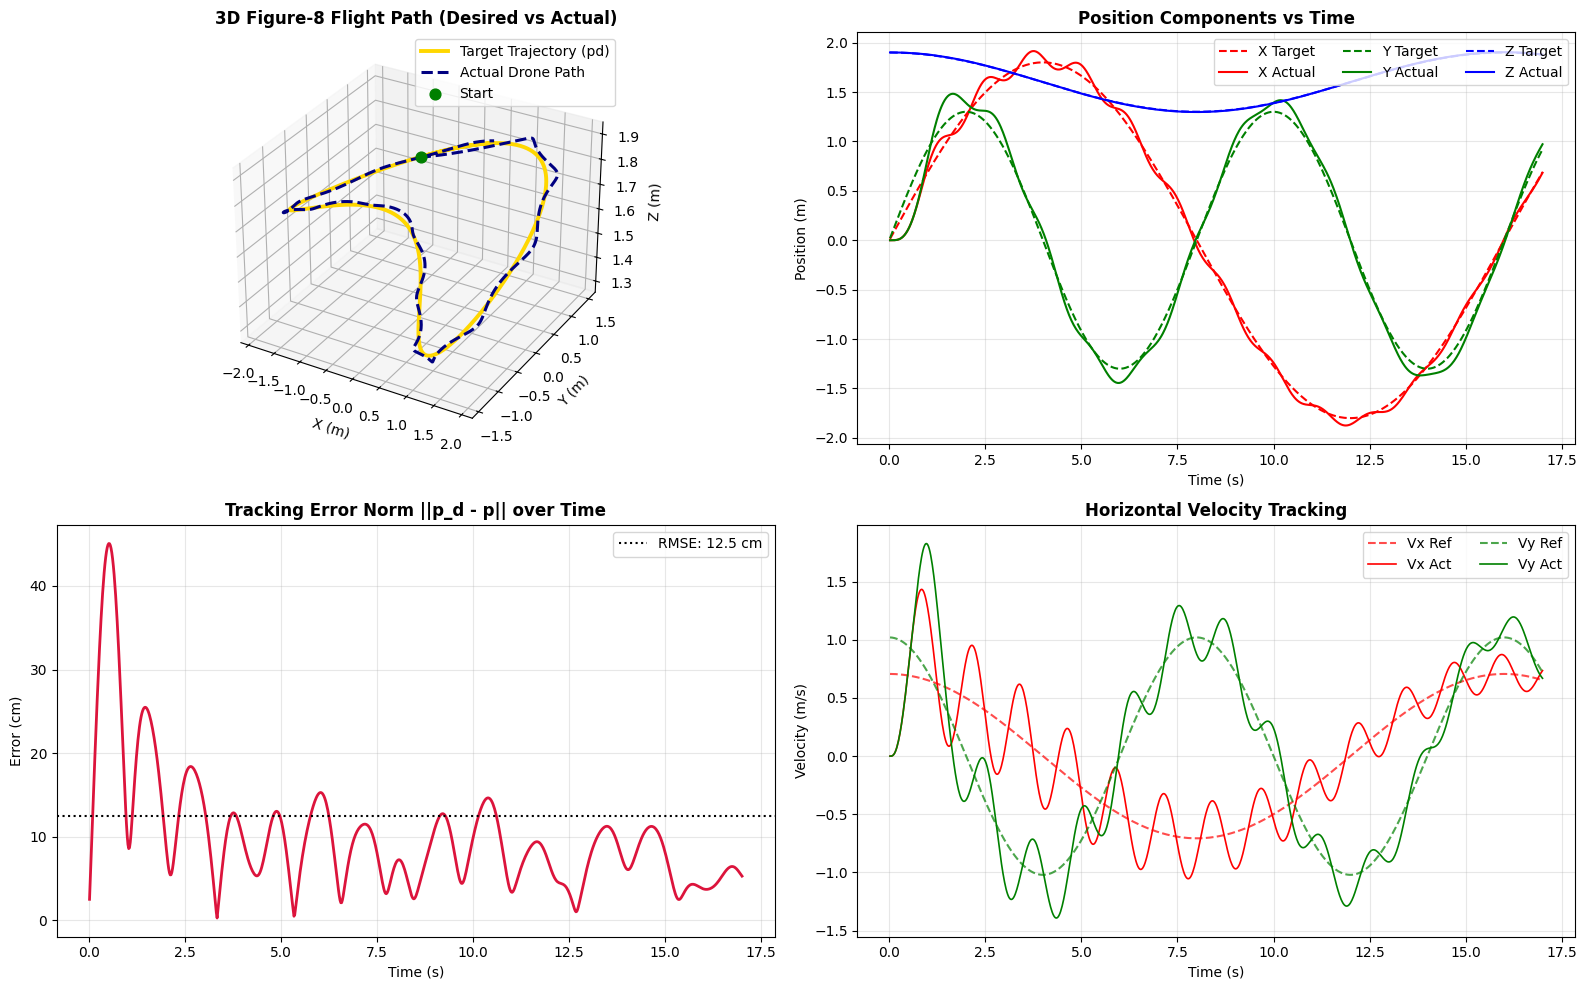

In [9]:
# Plot 3D Trajectory and Time History Curves
fig = plt.figure(figsize=(16, 10))

# 1. 3D Spatial Trajectory Comparison
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(target_pos_arr[:, 0], target_pos_arr[:, 1], target_pos_arr[:, 2], 'gold', lw=2.8, label='Target Trajectory (pd)')
ax1.plot(actual_pos_arr[:, 0], actual_pos_arr[:, 1], actual_pos_arr[:, 2], 'navy', lw=2.2, linestyle='--', label='Actual Drone Path')
ax1.scatter([target_pos_arr[0, 0]], [target_pos_arr[0, 1]], [target_pos_arr[0, 2]], color='green', s=60, label='Start')
ax1.set_title("3D Figure-8 Flight Path (Desired vs Actual)", fontsize=12, fontweight='bold')
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.legend(loc='upper right')

# 2. Component Tracking: X, Y, Z vs Time
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(time_arr, target_pos_arr[:, 0], 'r--', label='X Target')
ax2.plot(time_arr, actual_pos_arr[:, 0], 'r', lw=1.5, label='X Actual')
ax2.plot(time_arr, target_pos_arr[:, 1], 'g--', label='Y Target')
ax2.plot(time_arr, actual_pos_arr[:, 1], 'g', lw=1.5, label='Y Actual')
ax2.plot(time_arr, target_pos_arr[:, 2], 'b--', label='Z Target')
ax2.plot(time_arr, actual_pos_arr[:, 2], 'b', lw=1.5, label='Z Actual')
ax2.set_title("Position Components vs Time", fontsize=12, fontweight='bold')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Position (m)")
ax2.grid(True, alpha=0.3)
ax2.legend(ncol=3, loc='upper right')

# 3. Tracking Error Norm over Time
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(time_arr, error_arr * 100.0, 'crimson', lw=2.0)
ax3.axhline(rmse * 100.0, color='black', linestyle=':', label=f'RMSE: {rmse*100:.1f} cm')
ax3.set_title("Tracking Error Norm ||p_d - p|| over Time", fontsize=12, fontweight='bold')
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Error (cm)")
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Velocity Tracking (Feedforward + Actual)
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(time_arr, target_vel_arr[:, 0], 'r--', alpha=0.7, label='Vx Ref')
ax4.plot(time_arr, actual_vel_arr[:, 0], 'r', lw=1.2, label='Vx Act')
ax4.plot(time_arr, target_vel_arr[:, 1], 'g--', alpha=0.7, label='Vy Ref')
ax4.plot(time_arr, actual_vel_arr[:, 1], 'g', lw=1.2, label='Vy Act')
ax4.set_title("Horizontal Velocity Tracking", fontsize=12, fontweight='bold')
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Velocity (m/s)")
ax4.grid(True, alpha=0.3)
ax4.legend(ncol=2, loc='upper right')

plt.tight_layout()
plt.show()

In [10]:
# Display Trajectory Tracking Simulation Video
print("Displaying Trajectory Tracking Video (Arena Observer Camera):")
media.show_video(frames_exp2, fps=30)

Displaying Trajectory Tracking Video (Arena Observer Camera):


This browser does not support the video tag.


## Summary & Key Takeaways

In this tutorial on 3D trajectory tracking, you learned:
1. **Why Feedforward is Essential**: Pure feedback PID inherently lags behind moving targets. Incorporating reference velocity $\mathbf{v}_d(t)$ as feedforward eliminates lag and enables seamless high-speed path following.
2. **Moving Point Interception**: How the quadrotor can be commanded to intercept a dynamic, moving target point starting from an arbitrary spatial offset.
3. **Modular Trajectory Generation**: Implementing time-parameterized curves with closed-form position, velocity, and acceleration derivatives.
4. **Speed Scaling**: How adjusting `speed_scale` changes trajectory pace while preserving path geometry.
5. **Coordinated Heading**: Rotating the drone's yaw tangent to its flight path for realistic aerodynamic maneuvers.